# Results: LDPC vs CASCADE

Step-by-step extraction of the reconciliation-comparison data pipeline.

1. Load the raw NDJSON files into DataFrames.
2. Flatten the nested `{average, deviation}` metric objects.
3. Add a few derived columns (per-key-bit normalisations).
4. Build the **empirical SNR ↔ pre-correction BER mapping** from the LDPC data.
5. Define one reusable plot helper that uses the mapping to add a **secondary SNR axis**
   at the top of every comparison plot.
6. Plot directly-comparable metrics (BER, FER, efficiency, iterations).
7. Plot metrics that only become fair to compare once normalised per key bit.

**Why pre-correction BER is the primary x-axis.** CASCADE operates on a Binary Symmetric
Channel and only consumes a bit-error rate; LDPC operates on a Gaussian channel followed by
8D multidimensional reconciliation and only then produces a binary stream. The only variable
on which both algorithms see *equivalent channel difficulty* is the measured BER that enters
the decoder. SNR is shown on a secondary top axis using the empirical LDPC mapping so
CV-QKD readers still get their expected axis without introducing a false BPSK conversion
(8D reconciliation is not BPSK; see Leverrier 2008).


In [48]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy import special

plt.rcParams.update({
    "axes.grid": True,
    "grid.alpha": 0.25,       # faint
    "grid.linestyle": "-",
    "grid.linewidth": 0.6,
    "grid.color": "#b0b0b0",  # light grey on white
})

## 1. Load raw data

Each NDJSON row is one operating point (one `(algorithm, key_size, snr_or_qber)` combination),
with metrics stored as `{"average": ..., "deviation": ...}` dicts.


In [49]:
def load_ndjson(path):
    """Load an NDJSON file into a DataFrame (one row per line)."""
    with open(path) as f:
        return pd.DataFrame(json.loads(line) for line in f if line.strip())

LDPC_PATH    = "../data/LDPC/snr_sweep_0_to_7_5_1000frames_per_point.ndjson"
CASCADE_PATH = "../data/CASCADE/data__algorithm=original;key_size=10000;error_rate=vary"

ldpc_df    = load_ndjson(LDPC_PATH)
cascade_df = load_ndjson(CASCADE_PATH)

print(f"LDPC rows:    {len(ldpc_df)}  key_sizes: {sorted(ldpc_df['key_size'].unique())}")
print(f"CASCADE rows: {len(cascade_df)}  key_sizes: {sorted(cascade_df['key_size'].unique())}")


LDPC rows:    354  key_sizes: [np.int64(256), np.int64(1024), np.int64(2048)]
CASCADE rows: 596  key_sizes: [np.int64(10000)]


## 2. Flatten `{average, deviation}` metric dicts

Pull each metric out of its nested dict into `<metric>_avg` and `<metric>_std` columns.


In [50]:
METRICS = [
    "actual_bit_error_rate",
    "remaining_bit_error_rate",
    "remaining_frame_error_rate",
    "efficiency",
    "elapsed_process_time",
    "elapsed_real_time",
    "normal_iterations",
    "reconciliation_bits",
    "reconciliation_bits_per_key_bit",
    "ask_parity_messages",
    "biconf_iterations",
]

def flatten_metrics(df, metrics=METRICS):
    """For each metric, add <metric>_avg and <metric>_std columns."""
    for m in metrics:
        if m in df.columns:
            df[f"{m}_avg"] = df[m].apply(lambda x: x["average"]   if isinstance(x, dict) else x)
            df[f"{m}_std"] = df[m].apply(lambda x: x["deviation"] if isinstance(x, dict) else 0.0)
    return df

ldpc_df    = flatten_metrics(ldpc_df).sort_values(["key_size", "actual_bit_error_rate_avg"]).reset_index(drop=True)
cascade_df = flatten_metrics(cascade_df).sort_values(["key_size", "actual_bit_error_rate_avg"]).reset_index(drop=True)

ldpc_df[["key_size", "snr", "actual_bit_error_rate_avg", "efficiency_avg"]].head()


,key_size,snr,actual_bit_error_rate_avg,efficiency_avg
0,256,6.965370,0.014966,11.179380
1,256,6.332154,0.018121,9.554350
2,256,5.756504,0.021722,8.079081
3,256,5.233185,0.025859,6.873458
4,256,4.757441,0.030433,5.873728


## 3. Add derived columns

Elapsed time is absolute, so to compare algorithms fairly across different `key_size` values,
normalise to per-key-bit. `reconciliation_bits_per_key_bit` and `efficiency` are already
dimensionless, so nothing else is needed.


In [51]:
def add_per_key_bit_times(df):
    df["real_time_per_bit_avg"]    = df["elapsed_real_time_avg"]    / df["key_size"]
    df["process_time_per_bit_avg"] = df["elapsed_process_time_avg"] / df["key_size"]
    return df

ldpc_df    = add_per_key_bit_times(ldpc_df)
cascade_df = add_per_key_bit_times(cascade_df)


## 4. Empirical SNR ↔ pre-correction BER mapping

The LDPC pipeline is parameterised by SNR, but the measured pre-correction BER is what enters
the decoder (and what CASCADE's BSC equivalent is matched against). The mapping is fixed by
the 8D multidimensional-reconciliation preprocessor (Leverrier 2008); it is *not* the standard
BPSK curve $\tfrac12\mathrm{erfc}(\sqrt{\mathrm{SNR}})$, as shown below.

We build the mapping by averaging the measured BER across LDPC key sizes at each SNR (the
preprocessor is the same regardless of LDPC code), then use `np.interp` in both directions.
The resulting callables `ber_to_snr` / `snr_to_ber` feed `ax.secondary_xaxis` to put an
SNR axis on top of every BER plot.


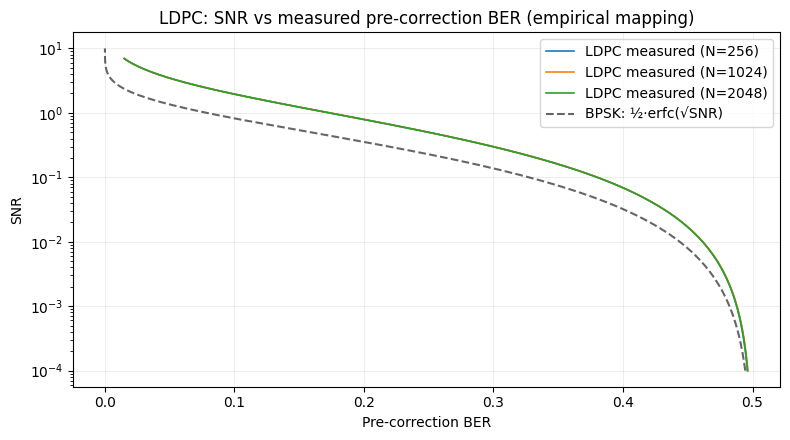

In [52]:
def build_ber_snr_mappers(ldpc_df):
    """Return (ber_to_snr, snr_to_ber) from the measured LDPC sweep.

    Both are vectorised, monotone over the sampled range, and clamp at the ends
    (np.interp default), which is what matplotlib's secondary_xaxis expects.
    """
    pts = (ldpc_df.groupby("snr", as_index=False)["actual_bit_error_rate_avg"].mean()
                  .sort_values("snr"))
    snr = pts["snr"].to_numpy()
    ber = pts["actual_bit_error_rate_avg"].to_numpy()

    order_b  = np.argsort(ber)
    ber_s    = ber[order_b]
    log_snr_s = np.log(snr[order_b])
    log_snr_sorted = np.log(snr)

    def ber_to_snr(b):
        return np.exp(np.interp(np.asarray(b, dtype=float), ber_s, log_snr_s))

    def snr_to_ber(s):
        s = np.asarray(s, dtype=float)
        safe = np.where(s > 0, s, np.min(snr))
        return np.interp(np.log(safe), log_snr_sorted, ber)

    return ber_to_snr, snr_to_ber

ber_to_snr, snr_to_ber = build_ber_snr_mappers(ldpc_df)

fig, ax = plt.subplots(figsize=(8, 4.5))
for key_size, grp in ldpc_df.groupby("key_size"):
    grp = grp.sort_values("snr")
    ax.plot(grp["actual_bit_error_rate_avg"], grp["snr"],
            marker=None, markersize=3, linewidth=1.2,
            label=f"LDPC measured (N={key_size})")

snr_theory = np.logspace(-4, 1, 200)
ax.plot(0.5 * special.erfc(np.sqrt(snr_theory)), snr_theory,
        "k--", alpha=0.6, label="BPSK: ½·erfc(√SNR)")

ax.set_yscale("log")
ax.set_xlabel("Pre-correction BER")
ax.set_ylabel("SNR")
ax.set_title("LDPC: SNR vs measured pre-correction BER (empirical mapping)")
ax.legend()
fig.tight_layout();


## 5. Plot helper: metric vs pre-correction BER (+ secondary SNR axis)

A single reusable function that:

- Uses the **measured pre-correction BER** (`actual_bit_error_rate_avg`) as the x-axis so
  LDPC and CASCADE line up on a common axis.
- Adds a **secondary SNR axis on top** via `ax.secondary_xaxis('top', functions=...)` using the
  empirical mapping from the previous section. Only SNR ticks whose corresponding BER falls
  inside the visible plot range are shown.
- Draws one line per `(series, key_size)` pair — line-style per series, colour per key size.
- Optionally shades a ±1σ band from the corresponding `_std` column.


In [53]:
import re

_LINE_STYLES = ["-", "--", "-.", ":"]
_DEFAULT_SNR_TICKS = [1e-4, 1e-3, 1e-2, 1e-1, 1e0, 0.5, 2, 5, 1e1]

def _keysize_colors(series_list):
    key_sizes = sorted({ks for df, _ in series_list for ks in df["key_size"].unique()})
    palette   = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    return {ks: palette[i % len(palette)] for i, ks in enumerate(key_sizes)}

def _fmt_snr(v):
    return f"{v:g}"

def _attach_snr_axis(ax, ber_range, snr_funcs, snr_ticks=_DEFAULT_SNR_TICKS):
    """Add a secondary SNR axis (top) driven by (ber_to_snr, snr_to_ber)."""
    b2s, s2b = snr_funcs
    sec = ax.secondary_xaxis("top", functions=(b2s, s2b))
    lo, hi = sorted(b2s(np.array(ber_range)))
    visible = [s for s in snr_ticks if lo <= s <= hi]
    if visible:
        sec.set_xticks(visible)
        sec.set_xticklabels([_fmt_snr(v) for v in visible])
    sec.set_xlabel("SNR (LDPC-input; empirical 8D-reconciliation mapping)")
    return sec

def _absorb_y_offset_into_label(ax, ylabel):
    """Hide matplotlib's y-axis offset text and fold the exponent into the y-label.

    Without this, small-magnitude metrics (e.g. s/bit ~ 1e-7) show a floating ``1e-7``
    at the top-left of the axes that collides with the secondary SNR axis label.
    """
    fmt = ticker.ScalarFormatter(useMathText=True)
    fmt.set_useOffset(False)
    fmt.set_scientific(True)
    ax.yaxis.set_major_formatter(fmt)
    ax.figure.canvas.draw()
    off = ax.yaxis.get_offset_text().get_text()
    if not off:
        ax.set_ylabel(ylabel)
        return
    ax.yaxis.offsetText.set_visible(False)
    m = re.match(r"^(.*?)\s*\[([^\]]+)\]\s*$", ylabel)
    if m:
        body, unit = m.group(1).strip(), m.group(2).strip()
        ax.set_ylabel(f"{body} [{off} {unit}]")
    else:
        ax.set_ylabel(f"{ylabel} [{off}]")

def plot_vs_ber(series_list, metric, ylabel,
                ber_range=(0.0, 0.5), ylim=None, title=None,
                show_band=True, marker="o", figsize=(8, 5),
                snr_funcs=(ber_to_snr, snr_to_ber), snr_ticks=_DEFAULT_SNR_TICKS,
                title_pad=22):
    """Plot <metric>_avg vs measured pre-correction BER for one or more (df, label) pairs."""
    fig, ax = plt.subplots(figsize=figsize)
    colors = _keysize_colors(series_list)

    for i, (df, label) in enumerate(series_list):
        ls = _LINE_STYLES[i % len(_LINE_STYLES)]
        for key_size, grp in df.groupby("key_size"):
            if f"{metric}_avg" not in grp.columns:
                continue
            grp  = grp.sort_values("actual_bit_error_rate_avg")
            x    = grp["actual_bit_error_rate_avg"].to_numpy()
            mask = (x >= ber_range[0]) & (x <= ber_range[1])
            if not mask.any():
                continue
            x = x[mask]
            y = grp[f"{metric}_avg"].to_numpy()[mask]
            ax.plot(x, y, ls, marker=marker, markersize=3, linewidth=1.5,
                    color=colors[key_size], label=f"{label} (N={key_size})")
            if show_band and f"{metric}_std" in grp.columns:
                s = grp[f"{metric}_std"].to_numpy()[mask]
                ax.fill_between(x, np.maximum(0, y - s), y + s,
                                alpha=0.15, color=colors[key_size])

    ax.set_xlim(ber_range)
    ax.set_xlabel("Pre-correction BER")
    if ylim is not None:
        ax.set_ylim(ylim)
    if title:
        ax.set_title(title, pad=title_pad)

    if snr_funcs is not None:
        _attach_snr_axis(ax, ber_range, snr_funcs, snr_ticks)

    _absorb_y_offset_into_label(ax, ylabel)

    ax.legend(loc="best")
    fig.tight_layout()
    return fig, ax


## 6. Directly comparable metrics vs pre-correction BER

These metrics are defined identically for LDPC and CASCADE, so plotting them on the same axis
is a fair comparison.


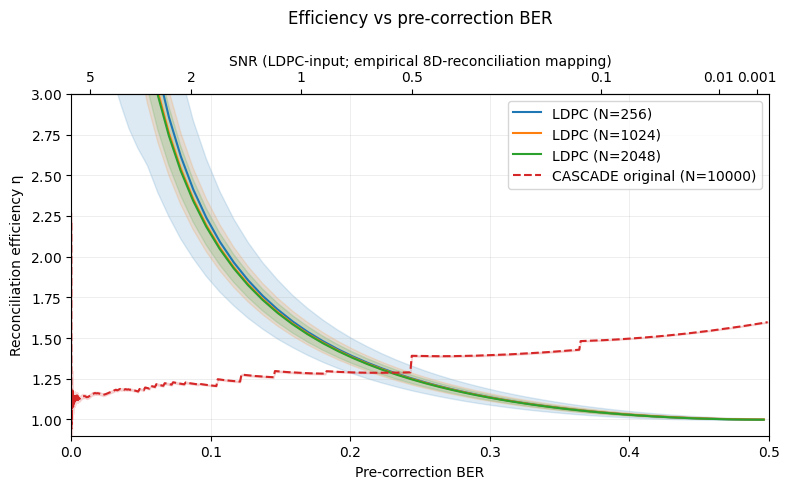

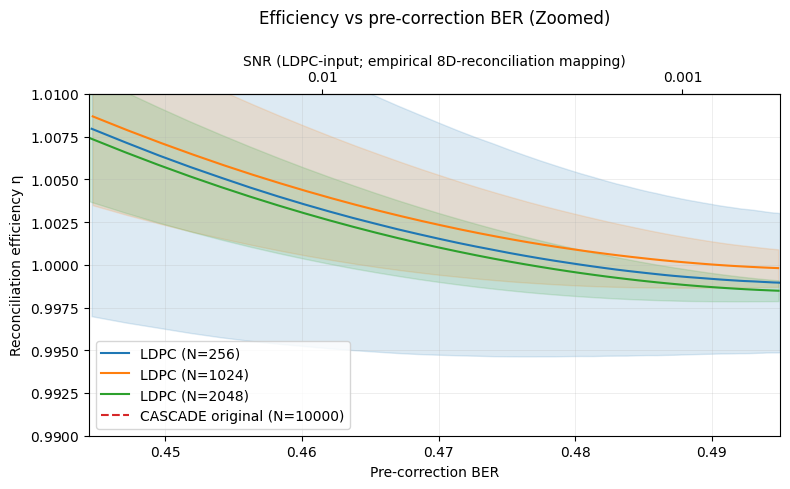

In [54]:
series = [(ldpc_df, "LDPC"), (cascade_df, "CASCADE original")]

plot_vs_ber(series, "efficiency", "Reconciliation efficiency η",
            ber_range=(0.0, 0.5), ylim=(0.9, 3.0),
            title="Efficiency vs pre-correction BER", marker=None);

plot_vs_ber(series, "efficiency", "Reconciliation efficiency η",
ber_range=(0.4444, 0.495), ylim=(0.99, 1.01),
title="Efficiency vs pre-correction BER (Zoomed)", marker=None);


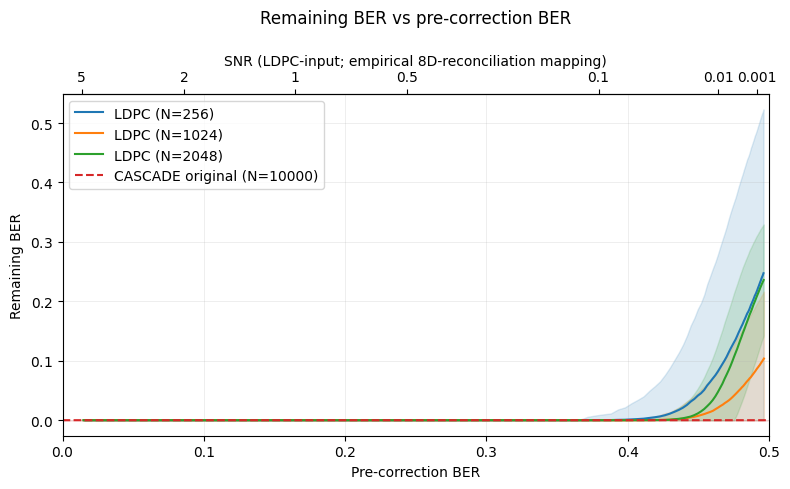

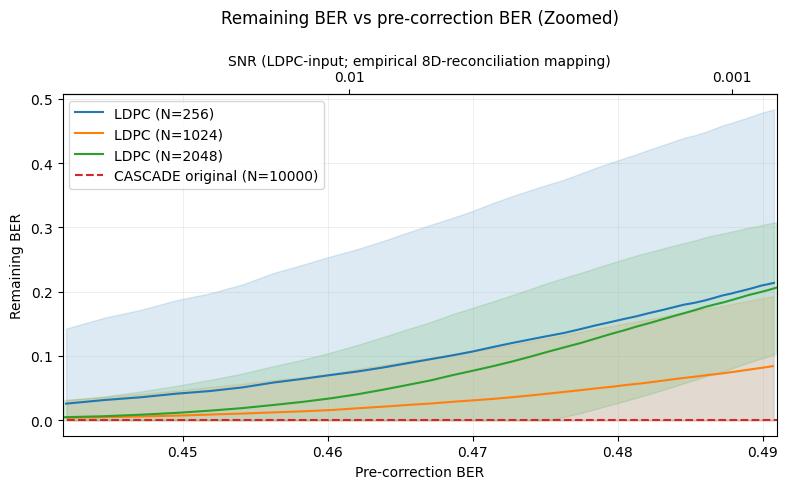

In [55]:
plot_vs_ber(series, "remaining_bit_error_rate", "Remaining BER",
            ber_range=(0.0, 0.50),
            title="Remaining BER vs pre-correction BER", marker=None);

plot_vs_ber(series, "remaining_bit_error_rate", "Remaining BER",
            ber_range=(0.4417, 0.491),
            title="Remaining BER vs pre-correction BER (Zoomed)", marker=None);


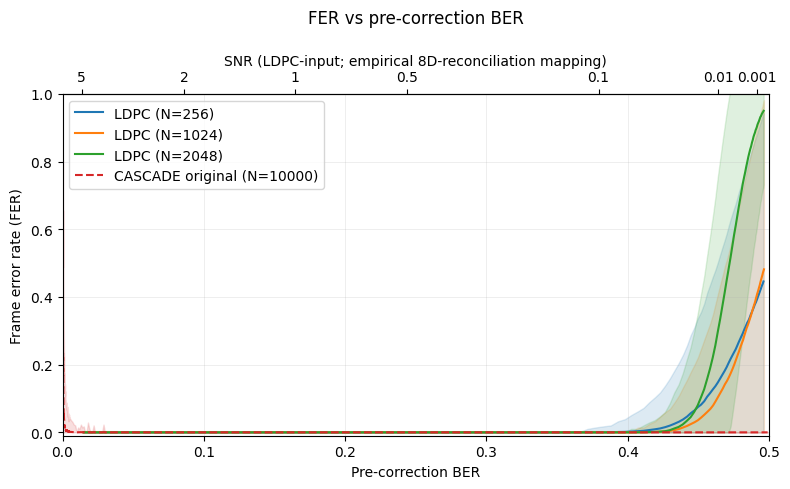

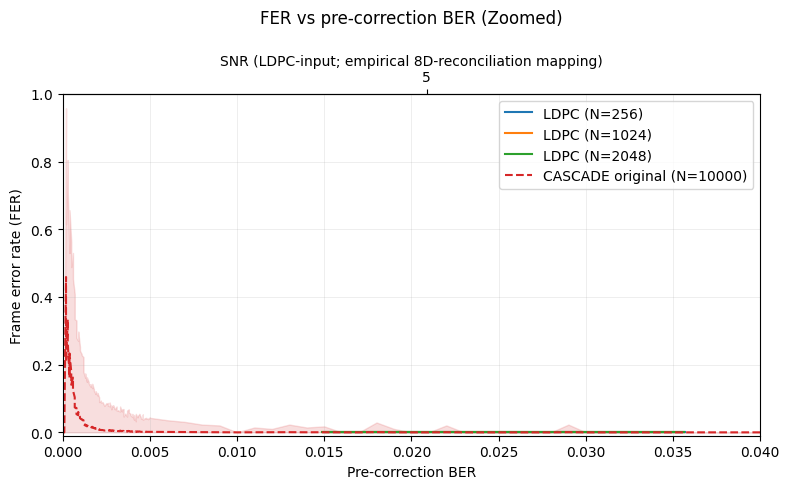

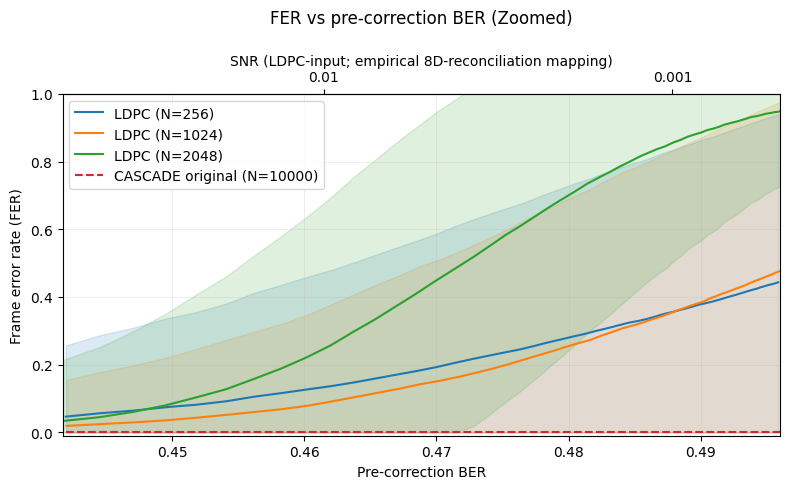

In [56]:
plot_vs_ber(series, "remaining_frame_error_rate", "Frame error rate (FER)",
            ber_range=(0.0, 0.5), ylim=(-0.01, 1.0),
            title="FER vs pre-correction BER", marker=None);

plot_vs_ber(series, "remaining_frame_error_rate", "Frame error rate (FER)",
            ber_range=(0.0, 0.04), ylim=(-0.01, 1.0),
            title="FER vs pre-correction BER (Zoomed)", marker=None);

plot_vs_ber(series, "remaining_frame_error_rate", "Frame error rate (FER)",
            ber_range=(0.4417, 0.496), ylim=(-0.01, 1.0),
            title="FER vs pre-correction BER (Zoomed)", marker=None);

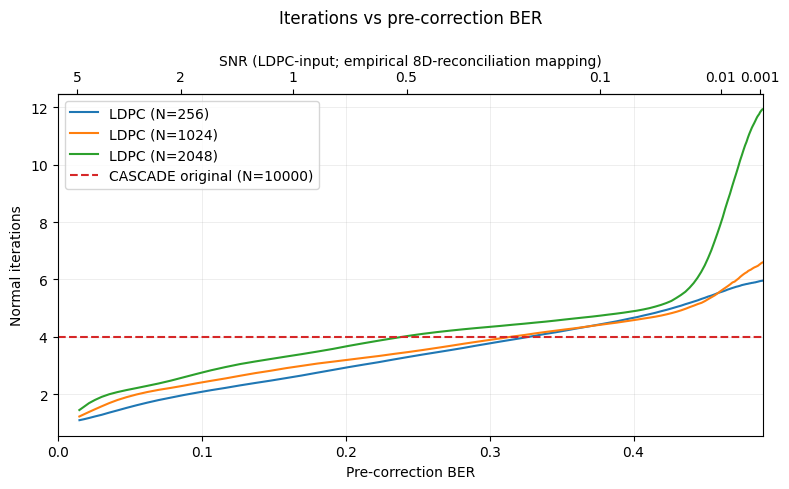

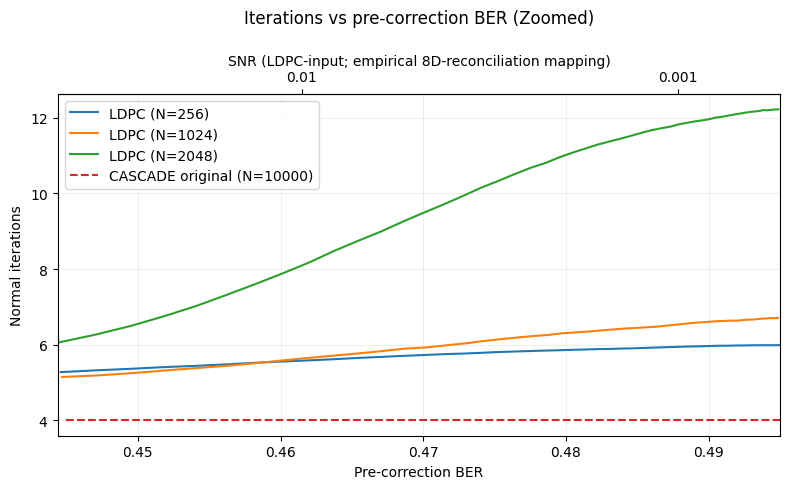

In [57]:
plot_vs_ber(series, "normal_iterations", "Normal iterations",
            ber_range=(0.0, 0.49),
            title="Iterations vs pre-correction BER",
            show_band=False, marker=None);

plot_vs_ber(series, "normal_iterations", "Normal iterations",
            ber_range=(0.4444, 0.495),
            title="Iterations vs pre-correction BER (Zoomed)",
            show_band=False, marker=None);

### 6a. Zoomed efficiency view (low-BER regime)

The literature (Mart\'inez-Mateo 2015, Mueller 2025) typically reports efficiency at
QBER $\le 0.1$. This zoomed view makes the dissertation directly comparable to those
references, in addition to the full-range plot above.


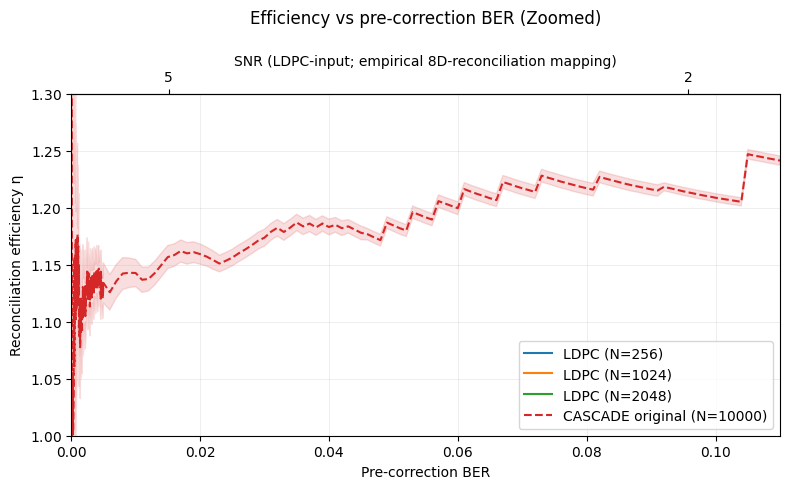

In [58]:
plot_vs_ber(series, "efficiency", "Reconciliation efficiency η",
            ber_range=(0.0, 0.11), ylim=(1.0, 1.3), marker=None,
            title="Efficiency vs pre-correction BER (Zoomed)");


### 6b. CASCADE interaction cost

LDPC is structurally one-way (a single syndrome transmission per frame), so
`ask_parity_messages` is a CASCADE-only metric. It is the number of sequential
round-trips and is the dominant driver of CASCADE latency once the link has
non-zero round-trip time (discussed in Part II).


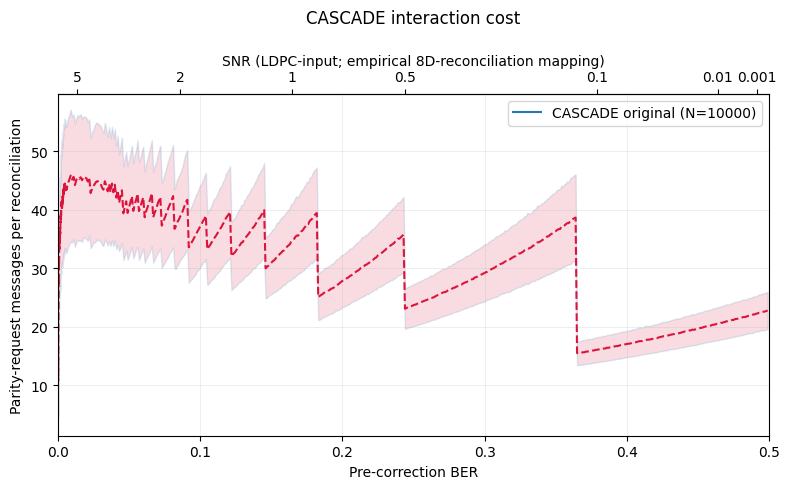

In [59]:
fig, ax = plot_vs_ber(
    [(cascade_df, "CASCADE original")],
    "ask_parity_messages",
    "Parity-request messages per reconciliation",
    ber_range=(0.0, 0.5),
    title="CASCADE interaction cost",
    show_band=True,
    marker=None,
)
cascade_color = "crimson"

for ln in ax.get_lines():
    ln.set_color(cascade_color)
    ln.set_linestyle("--")

for coll in ax.collections:
    coll.set_facecolor((*plt.matplotlib.colors.to_rgb(cascade_color), 0.15))


### 6c. Channel Noise matching

Measured pre-correction BER alignment used in the matched-condition
    LDPC/CASCADE comparison. Agreement supports the correctness of the
    alignment procedure independently of the reconciliation algorithms
    themselves.


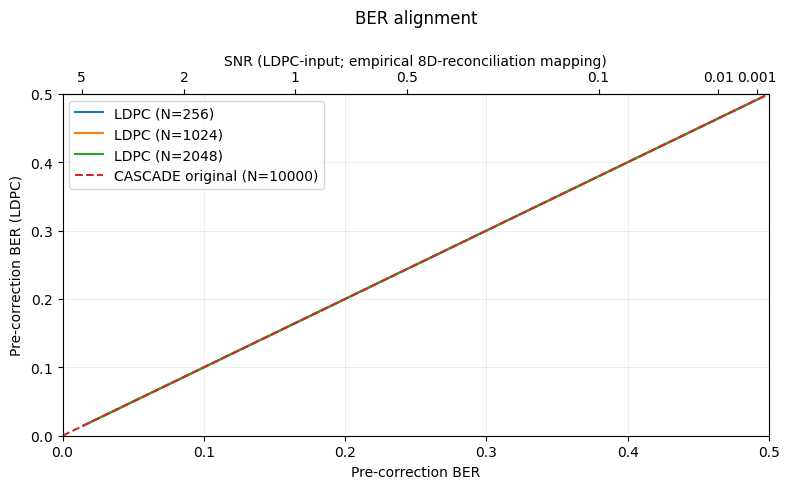

In [60]:
plot_vs_ber(series, "actual_bit_error_rate",
            "Pre-correction BER (LDPC)",
            ber_range=(0.0, 0.5),
            title="BER alignment",
            ylim=(0.0, 0.5),
            marker=None, show_band=False);

## 7. Normalised (per-key-bit) metrics

Absolute quantities (`reconciliation_bits`, `elapsed_*_time`) depend heavily on `key_size`, so
they are not directly comparable between LDPC (small frames, 256–2048) and CASCADE
(10 000-bit blocks). Normalising per key bit puts them on the same footing.


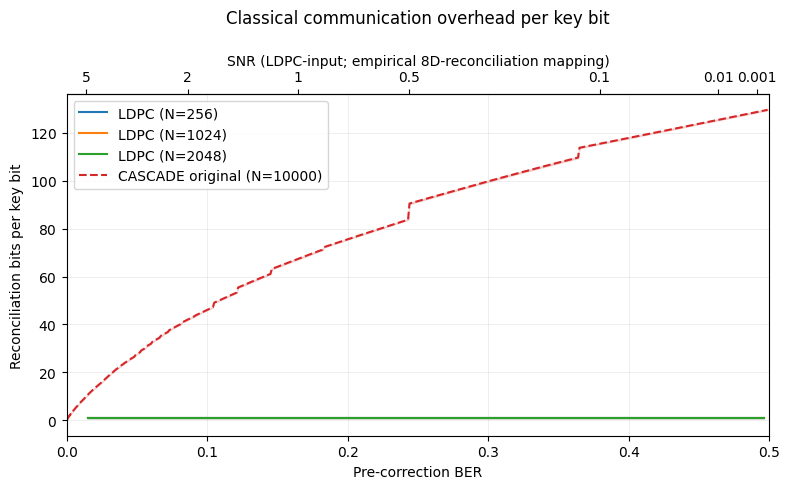

In [61]:
plot_vs_ber(series, "reconciliation_bits_per_key_bit",
            "Reconciliation bits per key bit",
            ber_range=(0.0, 0.5),
            title="Classical communication overhead per key bit",
            marker=None);


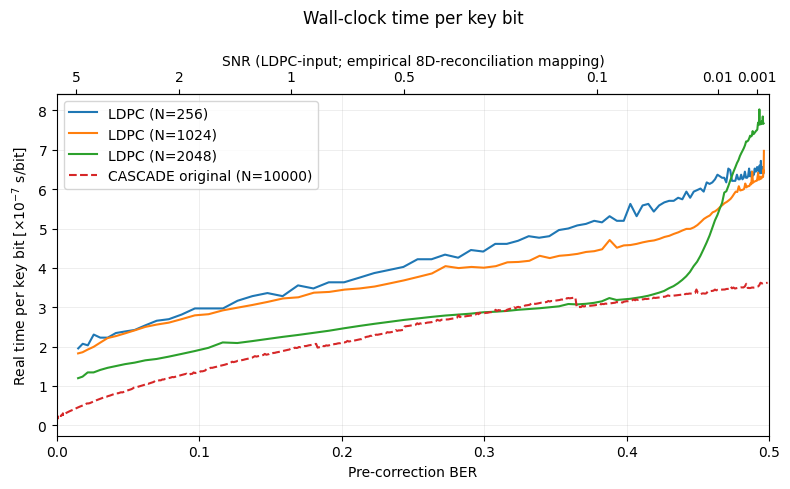

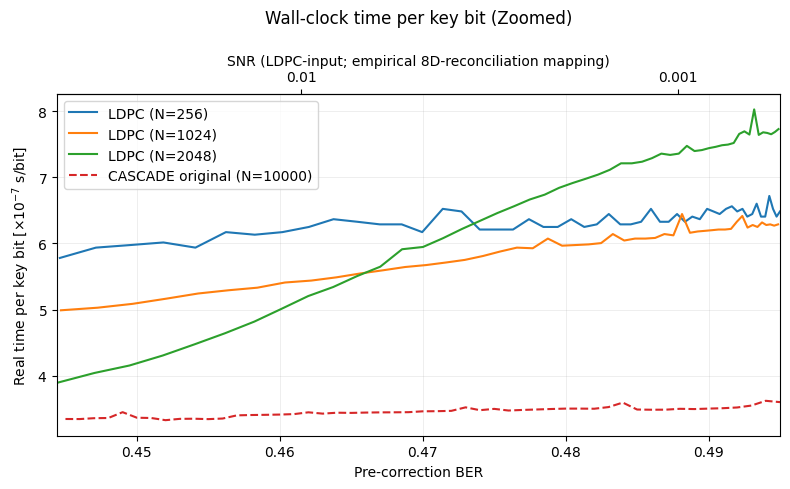

In [62]:
plot_vs_ber(series, "real_time_per_bit",
            "Real time per key bit [s/bit]",
            ber_range=(0.0, 0.5),
            title="Wall-clock time per key bit",
            show_band=True, marker=None);

plot_vs_ber(series, "real_time_per_bit",
            "Real time per key bit [s/bit]",
            ber_range=(0.4444, 0.495),
            title="Wall-clock time per key bit (Zoomed)",
            show_band=True, marker=None);

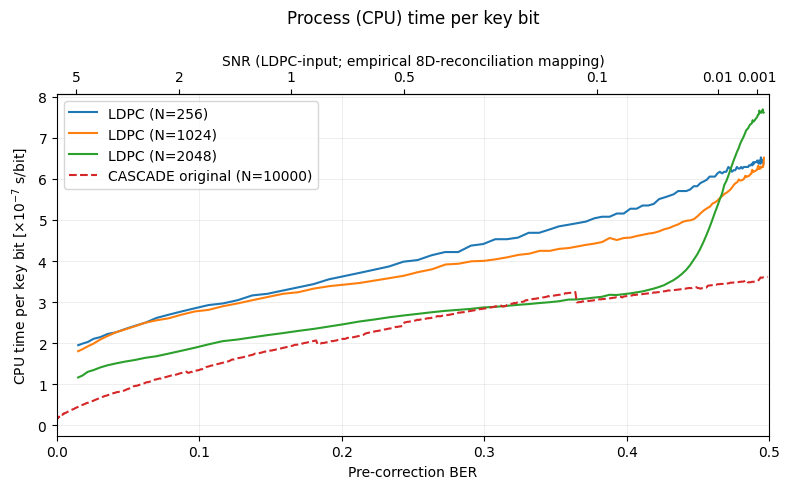

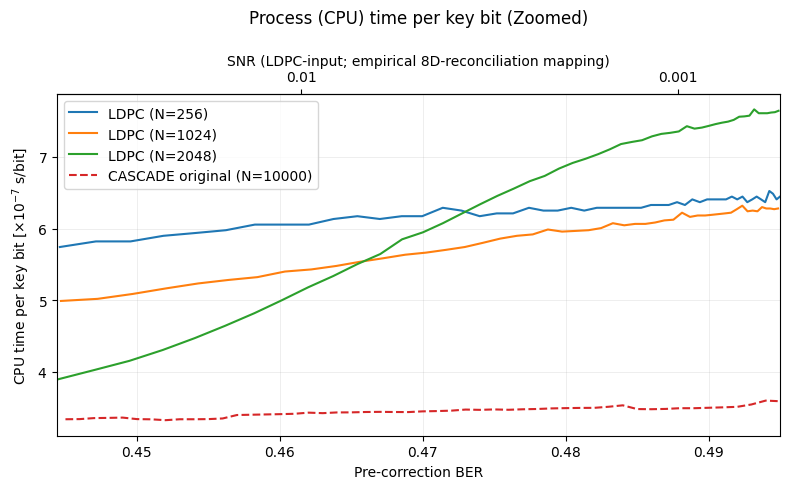

In [63]:
plot_vs_ber(series, "process_time_per_bit",
            "CPU time per key bit [s/bit]",
            ber_range=(0.000, 0.5),
            title="Process (CPU) time per key bit",
            show_band=True, marker=None);


plot_vs_ber(series, "process_time_per_bit",
            "CPU time per key bit [s/bit]",
            ber_range=(0.4444, 0.495),
            title="Process (CPU) time per key bit (Zoomed)",
            show_band=True, marker=None);